In [ ]:
# Colab cell 1
!pip install torch torchvision matplotlib tqdm numpy Pillow scikit-image
from google.colab import drive
drive.mount('/content/drive')  # follow auth steps
!mkdir -p /content/AI-FOREST/phase2_outputs
OUT_DIR = "/content/drive/MyDrive/AI-FOREST/phase2_outputs"  # persistent
!mkdir -p {OUT_DIR}


Mounted at /content/drive


In [ ]:
# Colab cell 2 - CA generator (paste the ca_simulator code from earlier)
import numpy as np
from PIL import Image
import os, random
def simulate_fire(seed_pos=(32,32), img_size=64, steps=12, p_spread=0.3, wind=(0,0)):
    frames = []
    fire = np.zeros((img_size, img_size), dtype=np.uint8)
    fire[seed_pos] = 1
    frames.append(fire.copy())
    for t in range(steps-1):
        new = fire.copy()
        for y in range(img_size):
            for x in range(img_size):
                if fire[y,x] == 1:
                    for dy in (-1,0,1):
                        for dx in (-1,0,1):
                            ny, nx = y+dy, x+dx
                            if 0 <= ny < img_size and 0 <= nx < img_size and (dy!=0 or dx!=0):
                                bias = 1.0 + 0.3*(dx*wind[0] + dy*wind[1])
                                prob = p_spread * max(0.0, bias)
                                if np.random.rand() < prob:
                                    new[ny,nx] = 1
        fire = new
        frames.append(fire.copy())
    return frames

def generate_ca_dataset(n_samples=500, img_size=64, steps=8, out_dir='train_masks'):
    os.makedirs(out_dir, exist_ok=True)
    for i in range(n_samples):
        seed = (np.random.randint(0,img_size), np.random.randint(0,img_size))
        wind = (np.random.uniform(-1,1), np.random.uniform(-1,1))
        frames = simulate_fire(seed, img_size=img_size, steps=steps, p_spread=np.random.uniform(0.15,0.5), wind=wind)
        frame = (frames[-1]*255).astype(np.uint8)
        Image.fromarray(frame).save(os.path.join(out_dir, f"ca_{i}.png"))
    print("Saved dataset to", out_dir)

generate_ca_dataset(n_samples=500, img_size=64, steps=8, out_dir='train_masks')


Saved dataset to train_masks


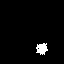

None

In [ ]:
from IPython.display import Image, display
display(Image('train_masks/ca_0.png'))
display(Image('train_masks/1.png') if os.path.exists('train_masks/1.png') else None)


In [ ]:
# Colab cell 3 - dataset & loader
import glob, torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class MaskDataset(Dataset):
    def __init__(self, folder, img_size=64):
        self.files = sorted(glob.glob(f"{folder}/*.png"))
        self.transform = T.Compose([T.Resize((img_size,img_size)), T.ToTensor()])  # [0,1]
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        p = self.files[idx]
        img = Image.open(p).convert('L')
        t = self.transform(img)
        return (t>0.5).float()  # binarize

ds = MaskDataset('train_masks', img_size=64)
loader = DataLoader(ds, batch_size=64, shuffle=True, num_workers=2)
next(iter(loader)).shape  # test


torch.Size([64, 1, 64, 64])

In [ ]:
# Colab cell 4 - VAE training (short)
import torch, torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Encoder ---
class Encoder(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 4, stride=2, padding=1)  # [B,32,32,32]
        self.conv2 = nn.Conv2d(32, 64, 4, stride=2, padding=1) # [B,64,16,16]
        self.conv3 = nn.Conv2d(64, 128, 4, stride=2, padding=1) # [B,128,8,8]
        self.fc_mu = nn.Linear(128*8*8, z_dim)
        self.fc_logvar = nn.Linear(128*8*8, z_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# --- Decoder ---
class Decoder(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128*8*8)
        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)  # [B,64,16,16]
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)   # [B,32,32,32]
        self.deconv3 = nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1)    # [B,1,64,64]

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1,128,8,8)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.sigmoid(self.deconv3(x))  # keep output in [0,1]
        return x

# --- VAE (combines Encoder & Decoder) ---
class VAE(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def decode(self, z):
        return self.decoder(z)


vae = VAE(z_dim=64).to(device)
opt = Adam(vae.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    vae.train()
    losses = []
    for xb in tqdm(loader):
        xb = xb.to(device)
        xrec, mu, logvar = vae(xb)
        rec_loss = F.binary_cross_entropy(xrec, xb, reduction='sum')
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (rec_loss + kld) / xb.shape[0]
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    print(f"Epoch {epoch} avg loss {sum(losses)/len(losses)}")
torch.save(vae.state_dict(), '/content/vae_ca.pth')
print("Saved /content/vae_ca.pth")


Device: cpu


100%|██████████| 8/8 [00:04<00:00,  1.82it/s]


Epoch 0 avg loss 1942.191650390625


100%|██████████| 8/8 [00:03<00:00,  2.20it/s]


Epoch 1 avg loss 648.3390197753906


...

Epoch 17 avg loss 194.68093490600586


100%|██████████| 8/8 [00:03<00:00,  2.31it/s]


Epoch 18 avg loss 186.4013500213623


100%|██████████| 8/8 [00:03<00:00,  2.45it/s]

Epoch 19 avg loss 181.3751106262207
Saved /content/vae_ca.pth


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = VAE(z_dim=64).to(device)
print("✅ VAE initialized on", device)


✅ VAE initialized on cpu


In [ ]:
from torch.optim import Adam

opt = Adam(vae.parameters(), lr=1e-3)

def loss_function(x_recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

epochs = 10  # start small
for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for batch in loader:  # dataloader is from your dataset step
        batch = batch.to(device)
        x_recon, mu, logvar = vae(batch)
        loss = loss_function(x_recon, batch, mu, logvar)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {total_loss/len(loader.dataset):.4f}")



Epoch 1/10, Avg Loss: 189.4458
Epoch 2/10, Avg Loss: 171.0489
Epoch 3/10, Avg Loss: 163.1106
Epoch 4/10, Avg Loss: 162.9577
Epoch 5/10, Avg Loss: 156.0040
Epoch 6/10, Avg Loss: 152.0175
Epoch 7/10, Avg Loss: 148.1453
Epoch 8/10, Avg Loss: 145.5604
Epoch 9/10, Avg Loss: 140.4533
Epoch 10/10, Avg Loss: 135.2928


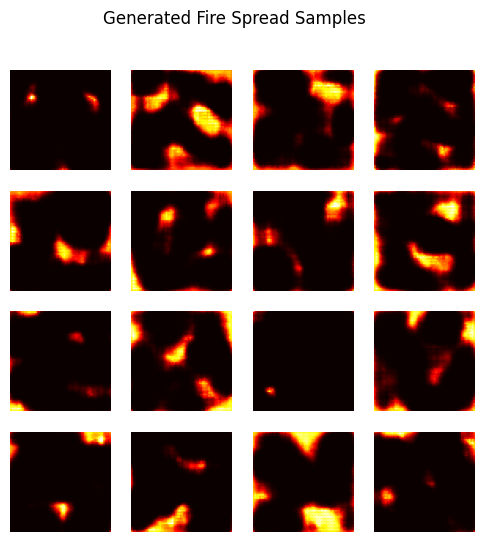

In [ ]:
import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    # sample random latent vectors
    z = torch.randn(16, 64).to(device)   # 16 samples, z_dim=64
    samples = vae.decode(z).cpu()        # Decode to fire maps

# plot generated fire spreads
fig, axs = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(samples[i].squeeze(), cmap="hot")
    ax.axis("off")
plt.suptitle("Generated Fire Spread Samples")
plt.show()
